# Spike Inference from Calcium Imaging Traces

**Objective:** infer discrete spike events from noisy dF/F calcium fluorescence traces, as a preprocessing step before ensemble identification.

**Method:** for each ROI (region of interest, i.e. imaged neuron), compute the derivative of the denoised dF/F trace and threshold it by a z-score cutoff (informed by each ROI's noise level) to flag spike events. Spot-check individual highly active ROIs to validate the threshold choice, then assemble per-trial spike events into a population array (ROIs x trials) used by every downstream notebook.


## Spike Inference: Derivative and Threshold

_Method_: Take first derivative of dF/F deNoised for an entire session for a given FOV and ROI. Use Z score to determine spiking threshold.

### 1. Determine Z Score Threshold

In [2]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')

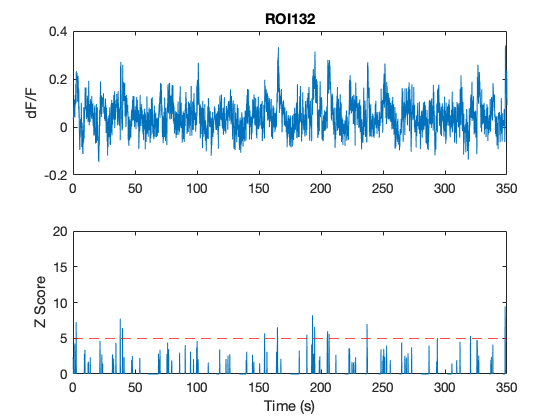

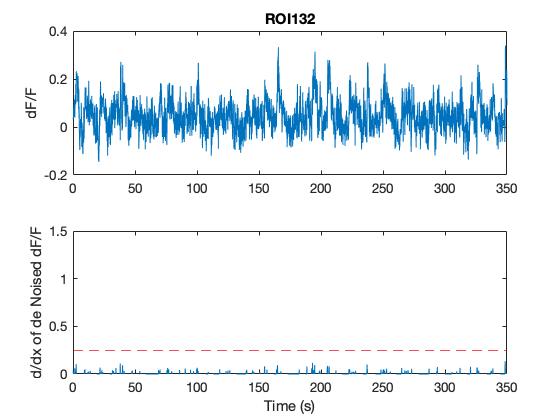

In [7]:
thresh = 5;
plot_zscore(data,frameRate,132, thresh);
figure(2)
plot_thrld(data, frameRate,132, 0.25)

In [13]:
plot(diff(dat_sorted{fov}.deNoise_dff.(roi).(stim),1, 2));

dat_sorted{fov}.spikes

Error using eval
Undefined function or variable 'roi'.



Using a Z-score threshold of 5 seems to work well for most ROIs as shown in the trace above. 
However it misses some of the events in movies where the cell is more active:

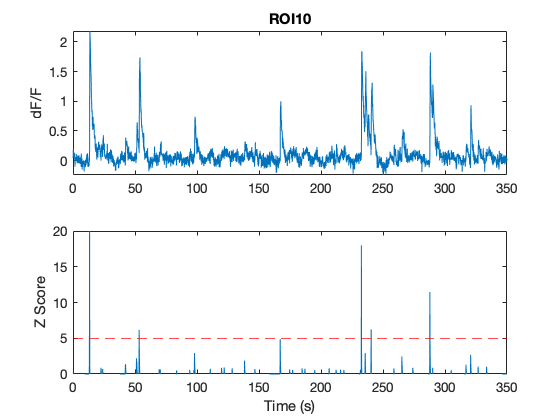

In [3]:
plot_zscore(data,frameRate,10, thresh);

and it captures noise for traces where there is sparse firing

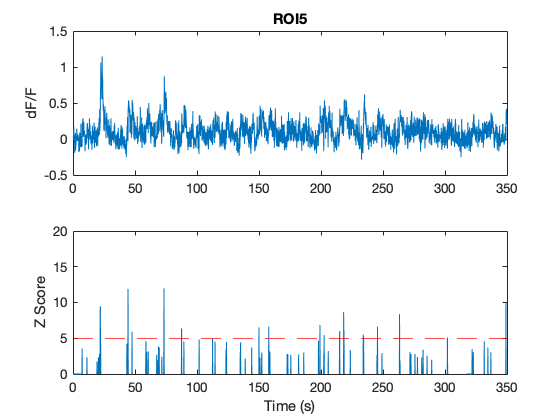

In [37]:
plot_zscore(data,frameRate,5, thresh);

ROIs with sparse firing have smaller std devs while more active ROIs have larger std devs resulting in a poor selection of threshold based on z score. After looking at the raw values for std devs for many ROIS, $\sigma = 0.25$ was the best choice, corresponding to a z score of ~ 5. 

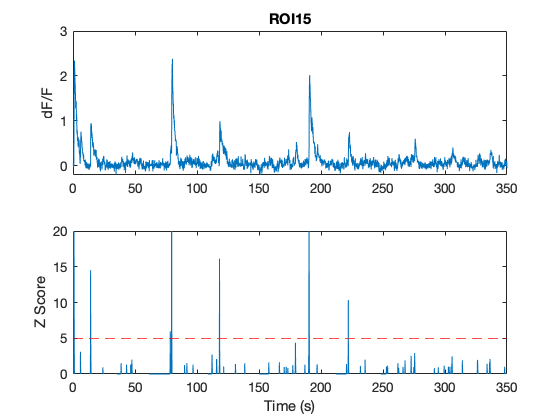

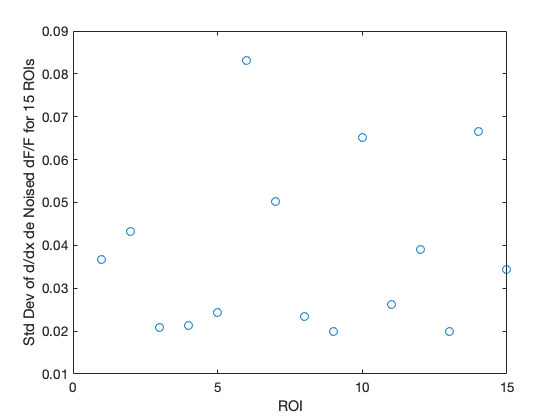

In [5]:
% Plot sigmas for first 15 ROIs 
sigmas = ones(15,1);
for i = 1:15
[z, mu, sigma] = plot_zscore(data,frameRate,i, thresh);
sigmas(i) = sigma;
end
figure(2)
plot(sigmas, 'o')
xlabel('ROI')
ylabel ('Std Dev of d/dx de Noised dF/F for 15 ROIs')

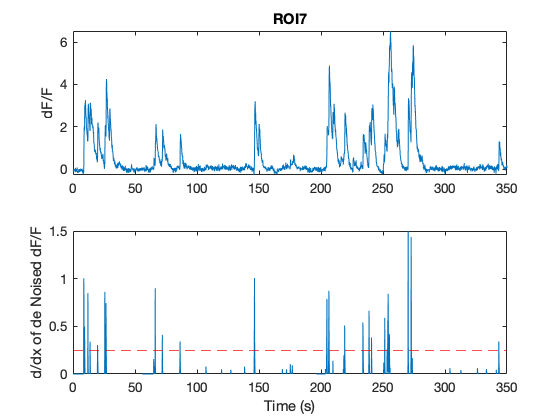

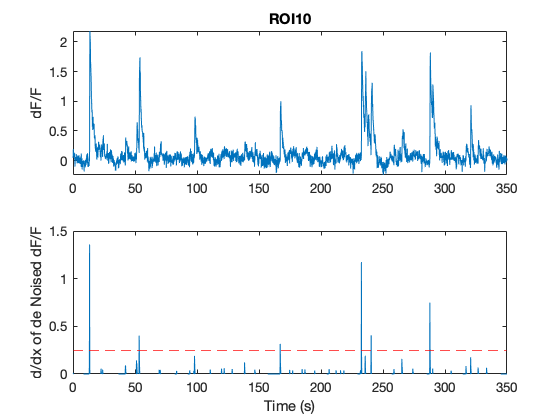

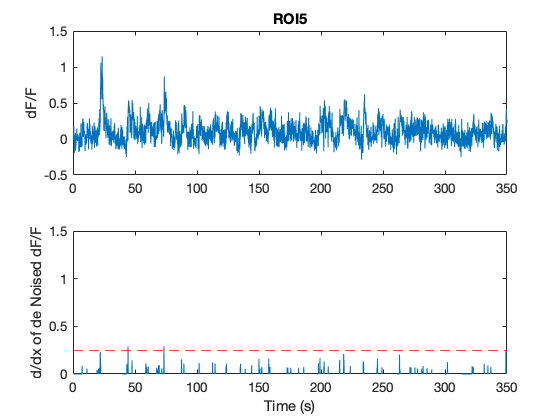

In [6]:
plot_thrld(data, frameRate,7, 0.25)
figure(2)
plot_thrld(data, frameRate,10, 0.25)
figure(3)
plot_thrld(data, frameRate,5, 0.25)

### 2. Create Population Array

Using an absolute threshold cutoff of $thrld = 0.25$, we can go ahead and build the population arrays for each stimulus type. A __population vector__ is formed by all the active and inactive neurons during a session where active cells are labelled 1 and inactive cells are labelled 0. The population array is composed of N population vectors each with bin width $\Delta t_\rm{bin}$. 

Here we make the choice of using a time bin of 1000 ms after stimulus onset. This means the population array is n neurons by N trials. This array will be fed to the neuronal ensemble alogrithm to identify groups of neurons with synchronous activity across different trials.

For blank trials where no stimulus is presented, the 3000 ms trial is divided in 3 x 1000 ms bins so the population array contains 3 bins from each trial.

The function below retrieves the population array for a stimulus type for a given session. 

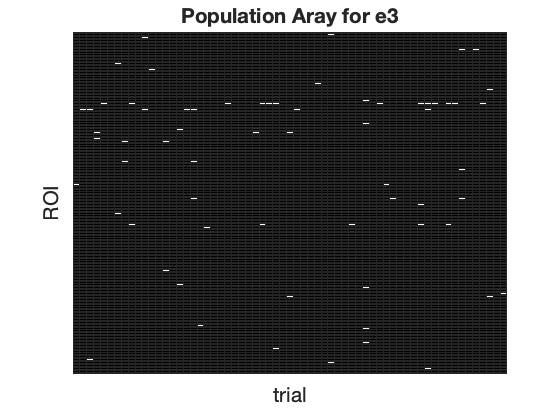

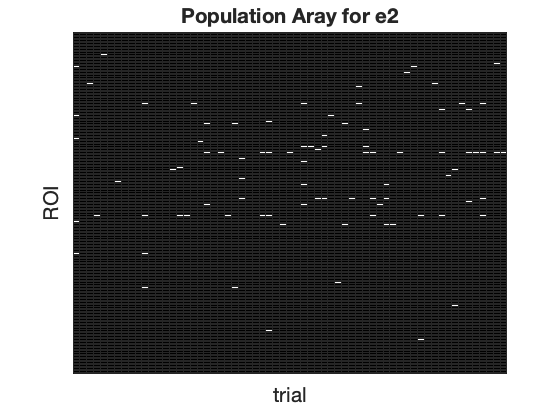

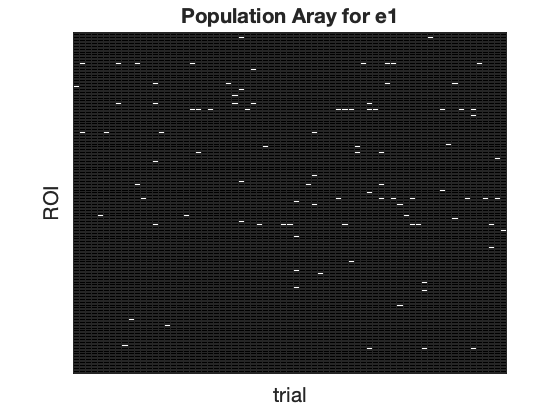

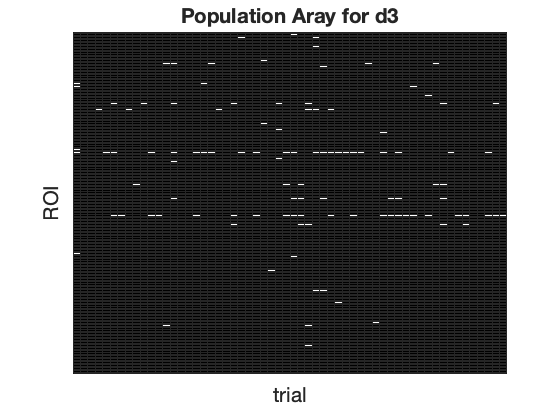

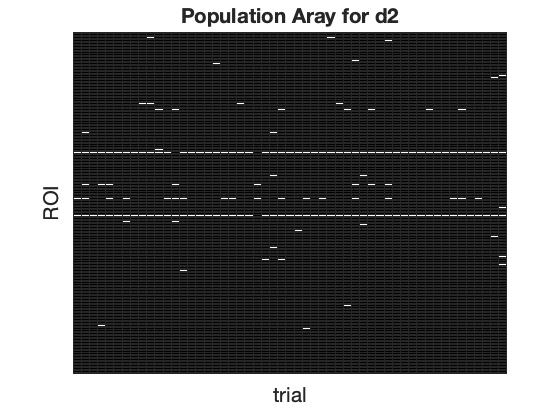

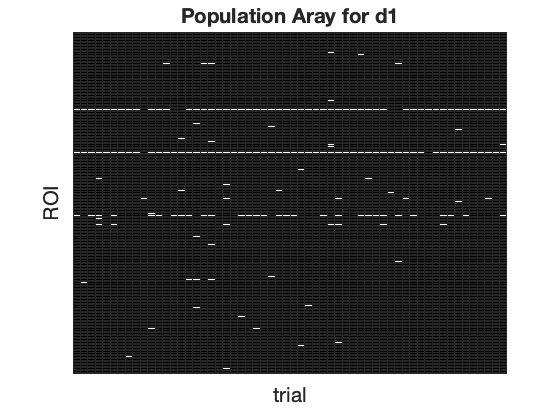

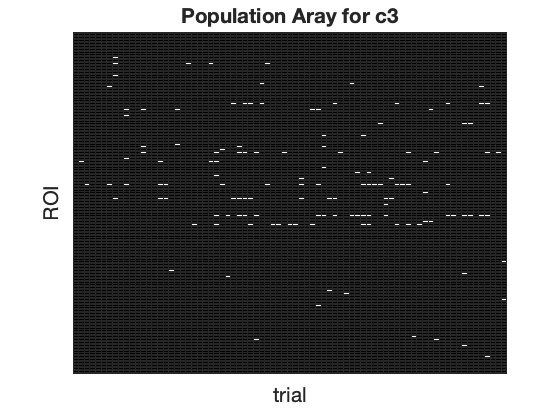

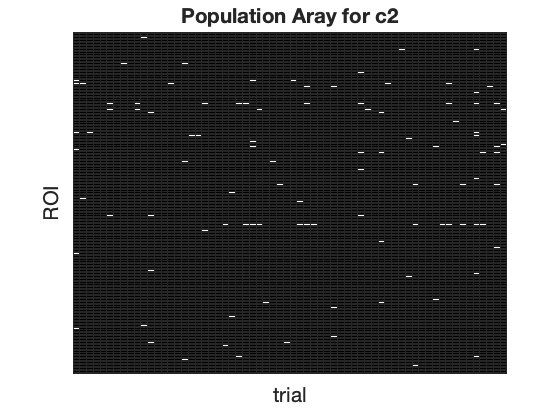

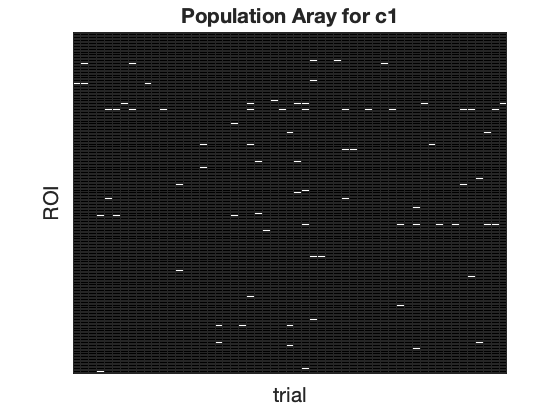

In [16]:
thrld = 0.25;
fov = 4;
tbin = 1; % 1 second time bin
t_start = 7;
stimulus = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1', 'blank'};
stim_num = 1; % stimulus corresponds to e3 and so forth

% Get spike array for 9 stimulus 
for stim = 1:length(stimulus)-1
    events_stim = get_spikes_stim(dat_sorted,fov,thrld, t_start,tbin,stim);
    figure(stim)
    plot_poparray(events_stim, stim)
    set(gca,'FontSize', 14)
end

Some of the ROIs above are very active across trials, worth checking individually to make sure its a not an issue with threshold. 

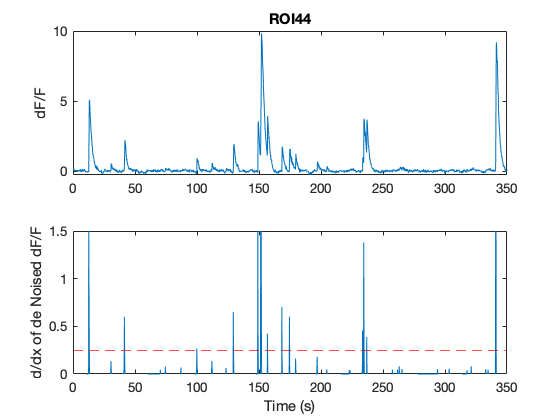

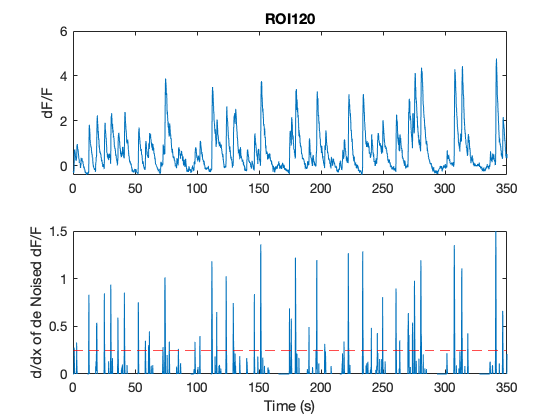

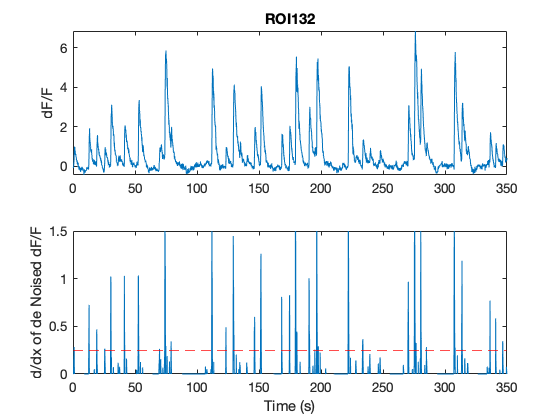

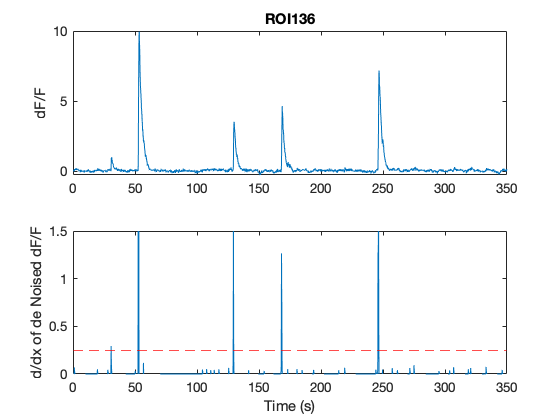

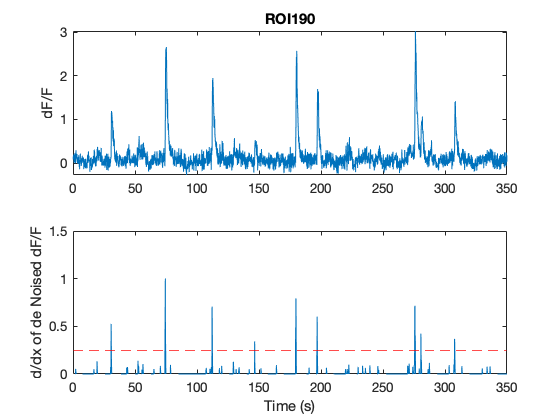

In [8]:
roi2check = [44,120,132,136,190];

for roi = 1:length(roi2check)
    figure(roi)
    plot_thrld(data, frameRate,roi2check(roi), 0.25)
end

ROI 120 and 130 seems to be very active, threshold seems okay? could raise to 0.3

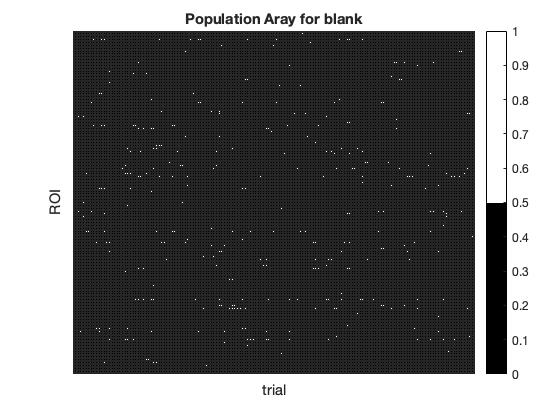

In [13]:
% Look at Spontaneous Data
thrld = 0.25;
fov = 1;

events_spont = get_spikes_spont(dat_sorted,fov,tbin,thrld);
plot_poparray(events_spont, 10)